# 02 — Vanilla Diffusion Policy Baseline

분리된 구조 (`src/*.py`) 기반의 깨끗한 Step 2 노트북.

**선행 조건**:
- `01_data_pipeline.ipynb` 실행 완료 → `demos_ant_planC.npz`, `norm_stats.npz` 가 Drive에 있음
- `src/dataset.py`, `src/models.py`, `src/training.py`, `src/sampling.py` 가 Drive에 있음

**이 노트북에서 하는 것**:
1. Drive mount + `src/` import + 데이터 로드
2. Conditional 1D U-Net 빌드 + sanity forward
3. DDPM training (또는 기존 ckpt 로드)
4. DDIM sampling sanity (offline)
5. Ant 환경 rollout sanity

**제안서 §6.3 baseline의 두 번째 항목** — 이 모델이 작동해야 phase-conditioned 비교 baseline이 됨.

## 1. Setup — Drive mount + src import

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os
PROJECT_DIR = '/content/drive/MyDrive/quadruped_diffusion_project'
SRC_DIR = f'{PROJECT_DIR}/src'
assert os.path.exists(SRC_DIR), f"src 폴더 없음: {SRC_DIR}"
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

# autoreload: src/*.py 수정하면 import된 함수도 자동 갱신
#%load_ext autoreload
#%autoreload 2

print(f"✓ Drive mounted")
print(f"✓ src 경로 등록: {SRC_DIR}")
print(f"  파일: {[f for f in os.listdir(SRC_DIR) if f.endswith('.py')]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Drive mounted
✓ src 경로 등록: /content/drive/MyDrive/quadruped_diffusion_project/src
  파일: ['dataset.py', 'models.py', 'training.py', 'sampling.py']


## 2. diffusers 설치 + import

런타임을 새로 시작했다면 diffusers가 없을 수 있음. 이미 있으면 빠르게 통과.

In [2]:
!pip install -q "diffusers>=0.30,<0.32" "huggingface_hub>=0.23"
print("✓ diffusers 준비 완료")

✓ diffusers 준비 완료


In [3]:
import math
import time
import shutil
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from diffusers.schedulers.scheduling_ddpm import DDPMScheduler
from diffusers.training_utils import EMAModel

# src 모듈
from dataset  import load_project_data, build_loaders
from models   import build_vanilla_dp_model, count_params
from training import (
    train_diffusion_policy, vanilla_cond_fn,
    save_checkpoint, load_checkpoint,
)
from sampling import (
    sample_action_chunk, rollout, rollout_multi_seed,
    vanilla_sample_cond_fn, diagnose_obs_distribution,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"PyTorch {torch.__version__}, device={device}")

PyTorch 2.10.0+cu128, device=cuda


## 3. 데이터 로드 + DataLoader 구성

이 두 줄로 Step 1 산출물을 다 가져옴.

In [4]:
data = load_project_data(PROJECT_DIR)

print(f"OBS_DIM={data['OBS_DIM']}, ACT_DIM={data['ACT_DIM']}")
print(f"obs_horizon={data['OBS_HORIZON']}, pred_horizon={data['PRED_HORIZON']}, "
      f"action_horizon={data['ACTION_HORIZON']}")
print(f"Train: {len(data['train_eps'])} eps | Val: {len(data['val_eps'])} eps")
print(f"Freq window: {data['freq_window_mean']:.3f} ± {data['freq_window_std']:.3f} Hz")

# Reproducibility
SEED = data['seed']
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

BATCH_SIZE = 256
train_ds, val_ds, train_loader, val_loader = build_loaders(
    data, batch_size=BATCH_SIZE, num_workers=2,
)

OBS_DIM=105, ACT_DIM=8
obs_horizon=2, pred_horizon=16, action_horizon=8
Train: 102 eps | Val: 18 eps
Freq window: 2.023 ± 0.102 Hz
Train dataset:
  AntPhaseDataset: 102 episodes → 18768 chunks
Val dataset:
  AntPhaseDataset: 18 episodes → 3312 chunks
  Train batches/epoch: 73
  Val batches/epoch:   13


## 4. 모델 빌드 + sanity forward

In [5]:
model = build_vanilla_dp_model(
    obs_dim=data['OBS_DIM'],
    act_dim=data['ACT_DIM'],
    obs_horizon=data['OBS_HORIZON'],
    diffusion_step_embed_dim=256,
    down_dims=(256, 512, 1024),
    device=device,
)
n = count_params(model)
print(f"Total params:     {n['total']/1e6:.2f}M")
print(f"Trainable params: {n['trainable']/1e6:.2f}M")

# Sanity forward
B = 4
fake_action = torch.randn(B, data['PRED_HORIZON'], data['ACT_DIM'], device=device)
fake_t = torch.randint(0, 100, (B,), device=device)
fake_cond = torch.randn(B, data['OBS_HORIZON'] * data['OBS_DIM'], device=device)
with torch.no_grad():
    out = model(fake_action, fake_t, fake_cond)
assert out.shape == fake_action.shape
print(f"\n✓ Forward pass: in {tuple(fake_action.shape)} → out {tuple(out.shape)}")

Total params:     68.23M
Trainable params: 68.23M

✓ Forward pass: in (4, 16, 8) → out (4, 16, 8)


## 5. Noise scheduler (DDPM)

In [6]:
NUM_TRAIN_TIMESTEPS = 100
NUM_INFERENCE_STEPS  = 16

noise_scheduler = DDPMScheduler(
    num_train_timesteps=NUM_TRAIN_TIMESTEPS,
    beta_schedule='squaredcos_cap_v2',
    prediction_type='epsilon',
    clip_sample=True,
)
print(f"DDPM: {NUM_TRAIN_TIMESTEPS} train steps, "
      f"{noise_scheduler.config.beta_schedule}, "
      f"{noise_scheduler.config.prediction_type}-prediction")

# Sampling 함수에 넘길 dict (DDIM scheduler가 같은 config로 만들어짐)
ns_config = {
    'num_train_timesteps': noise_scheduler.config.num_train_timesteps,
    'beta_schedule':       noise_scheduler.config.beta_schedule,
    'prediction_type':     noise_scheduler.config.prediction_type,
    'clip_sample':         noise_scheduler.config.clip_sample,
}

DDPM: 100 train steps, squaredcos_cap_v2, epsilon-prediction


## 6. 학습 또는 기존 ckpt 로드

`TRAIN=True`면 학습 실행 (T4 기준 100 epoch ≈ 15–25분).
`TRAIN=False`면 Drive의 기존 ckpt 로드 (학습 다시 안 돌림).

### 분리 구조 검증 시나리오

이미 합쳐진 노트북에서 학습한 ckpt가 있다면:
1. 그 ckpt를 `{PROJECT_DIR}/vanilla_dp_ckpt.pt` 경로로 저장 (이미 그 경로일 것)
2. 여기서 `TRAIN=False`로 두고 실행
3. Sampling/rollout 셀이 정상 작동하면 → src 분리 성공

In [8]:
TRAIN = False   # 학습된 ckpt가 이미 있으면 False
NUM_EPOCHS = 100
CKPT_PATH = f'{PROJECT_DIR}/vanilla_dp_ckpt.pt'

ema = EMAModel(parameters=model.parameters(), power=0.75)

if TRAIN:
    train_losses, val_log, best_ema_state = train_diffusion_policy(
        model, ema, noise_scheduler,
        train_loader, val_loader,
        cond_fn=vanilla_cond_fn,
        num_epochs=NUM_EPOCHS,
        lr=1e-4,
        weight_decay=1e-6,
        warmup_steps=500,
        val_every=5,
        log_every_step=100,
        device=device,
    )
    save_checkpoint(
        CKPT_PATH, model, ema, train_losses, val_log, best_ema_state,
        config={
            'OBS_DIM':  data['OBS_DIM'],   'ACT_DIM':  data['ACT_DIM'],
            'OBS_HORIZON':  data['OBS_HORIZON'],
            'PRED_HORIZON': data['PRED_HORIZON'],
            'NUM_TRAIN_TIMESTEPS': NUM_TRAIN_TIMESTEPS,
            'NUM_INFERENCE_STEPS': NUM_INFERENCE_STEPS,
        },
    )
else:
    meta = load_checkpoint(CKPT_PATH, model, ema, device=device)
    train_losses    = meta['train_losses']
    val_log         = meta['val_log']
    best_ema_state  = meta['best_ema_state']

USE_BEST_EMA = True

if USE_BEST_EMA and best_ema_state is not None:
    # ema의 state_dict 형태를 유지하면서 best 값들로 덮어쓰기
    cur = ema.state_dict()
    cur.update(best_ema_state)
    ema.load_state_dict(cur)
    print(f"✓ Best EMA 적용 (epoch 50, val ≈ 0.119)")
elif best_ema_state is None:
    print("⚠ best_ema_state 없음 — Final EMA 사용")
else:
    print("Final EMA 사용 (epoch 100, val ≈ 0.145)")

✓ Loaded: /content/drive/MyDrive/quadruped_diffusion_project/vanilla_dp_ckpt.pt
  Last val: (100, 0.14523430075496435)
✓ Best EMA 적용 (epoch 50, val ≈ 0.119)


## 7. Loss curve

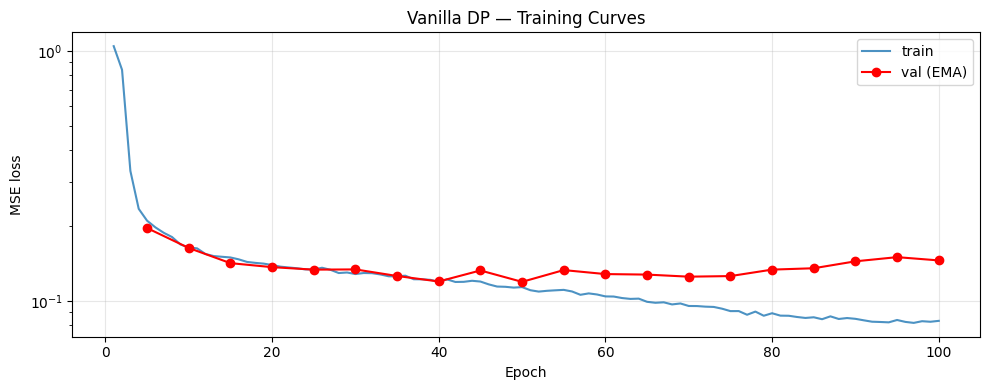

✓ /content/drive/MyDrive/quadruped_diffusion_project/vanilla_dp_loss.png


In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(np.arange(1, len(train_losses) + 1), train_losses, label='train', alpha=0.8)
if val_log:
    val_epochs = [v[0] for v in val_log]
    val_vals   = [v[1] for v in val_log]
    ax.plot(val_epochs, val_vals, 'o-', label='val (EMA)', color='red')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE loss')
ax.set_title('Vanilla DP — Training Curves')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_yscale('log')
plt.tight_layout()
out_png = f'{PROJECT_DIR}/vanilla_dp_loss.png'
plt.savefig(out_png, dpi=80, bbox_inches='tight')
plt.show()
print(f"✓ {out_png}")

## 8. Offline sampling sanity

Val set의 obs window 64개로 chunk 샘플링 → 분포가 training과 비슷한지 확인.

In [10]:
# Val set에서 64개 batch 만들기
val_obs_list, val_act_true_list = [], []
for i in range(min(64, len(val_ds))):
    s = val_ds[i]
    val_obs_list.append(s['obs'])
    val_act_true_list.append(s['action'])
val_obs_batch = torch.stack(val_obs_list)
val_act_true  = torch.stack(val_act_true_list).numpy()

print(f"Sampling {len(val_obs_batch)} chunks (DDIM {NUM_INFERENCE_STEPS} steps)...")
t0 = time.time()
sampled = sample_action_chunk(
    model, ema, ns_config,
    obs_window=val_obs_batch,
    cond_fn=vanilla_sample_cond_fn,
    pred_horizon=data['PRED_HORIZON'],
    act_dim=data['ACT_DIM'],
    num_inference_steps=NUM_INFERENCE_STEPS,
    device=device,
).numpy()
print(f"  {time.time()-t0:.1f}s")

# 차원별 분포 비교
print(f"\n{'dim':>4} | {'true mean':>11} | {'sampled mean':>13} | "
      f"{'true std':>10} | {'sampled std':>12}")
for d in range(data['ACT_DIM']):
    print(f"{d:>4} | {val_act_true[:,:,d].mean():>11.3f} | "
          f"{sampled[:,:,d].mean():>13.3f} | "
          f"{val_act_true[:,:,d].std():>10.3f} | "
          f"{sampled[:,:,d].std():>12.3f}")

Sampling 64 chunks (DDIM 16 steps)...
  0.9s

 dim |   true mean |  sampled mean |   true std |  sampled std
   0 |      -0.258 |        -0.256 |      0.202 |        0.185
   1 |      -0.272 |        -0.282 |      0.293 |        0.285
   2 |       0.097 |         0.104 |      0.479 |        0.451
   3 |      -0.125 |        -0.128 |      0.386 |        0.337
   4 |      -0.172 |        -0.160 |      0.295 |        0.243
   5 |       0.112 |         0.119 |      0.218 |        0.190
   6 |      -0.137 |        -0.136 |      0.460 |        0.443
   7 |       0.115 |         0.110 |      0.322 |        0.291


/tmp/ipykernel_10834/2553512301.py:12: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10834/2553512301.py:12: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10834/2553512301.py:12: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10834/2553512301.py:14: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=80, bbox_inches='tight')
/tmp/ipykernel_10834/2553512301.py:14: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=80, bbox_inches='tight')
/tmp/ipykernel_10834/2553512301.py:14: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=80, bbox_inches='tight')
/usr/local/lib/python3.12/dist-pa

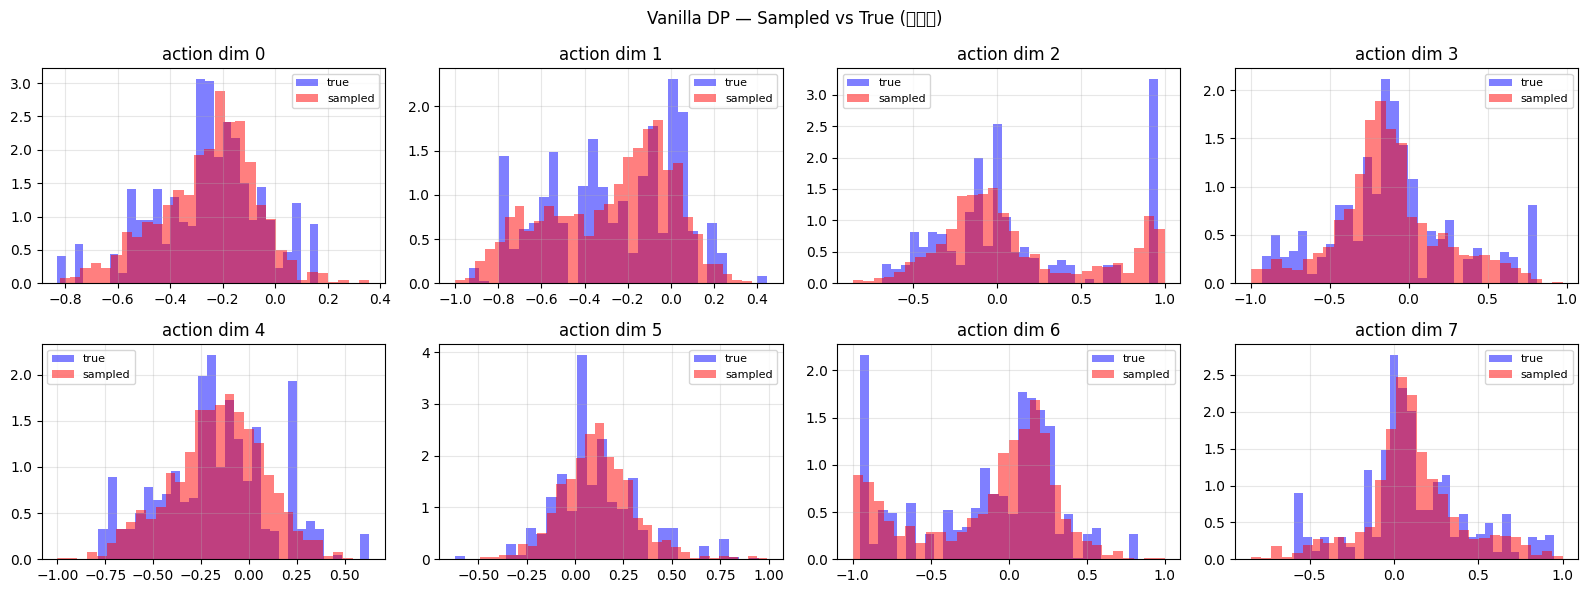

✓ /content/drive/MyDrive/quadruped_diffusion_project/vanilla_dp_action_dist.png


In [11]:
# Histogram 시각화
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for d in range(data['ACT_DIM']):
    ax = axes.flat[d]
    ax.hist(val_act_true[:,:,d].flatten(), bins=30, alpha=0.5,
            label='true', color='blue', density=True)
    ax.hist(sampled[:,:,d].flatten(), bins=30, alpha=0.5,
            label='sampled', color='red', density=True)
    ax.set_title(f'action dim {d}')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle('Vanilla DP — Sampled vs True (정규화)')
plt.tight_layout()
out_png = f'{PROJECT_DIR}/vanilla_dp_action_dist.png'
plt.savefig(out_png, dpi=80, bbox_inches='tight')
plt.show()
print(f"✓ {out_png}")

## 9. Chunk 시각화 — 같은 obs로 4번 샘플링

Diffusion stochasticity 확인. 약간 다르지만 비슷한 shape이어야 함.

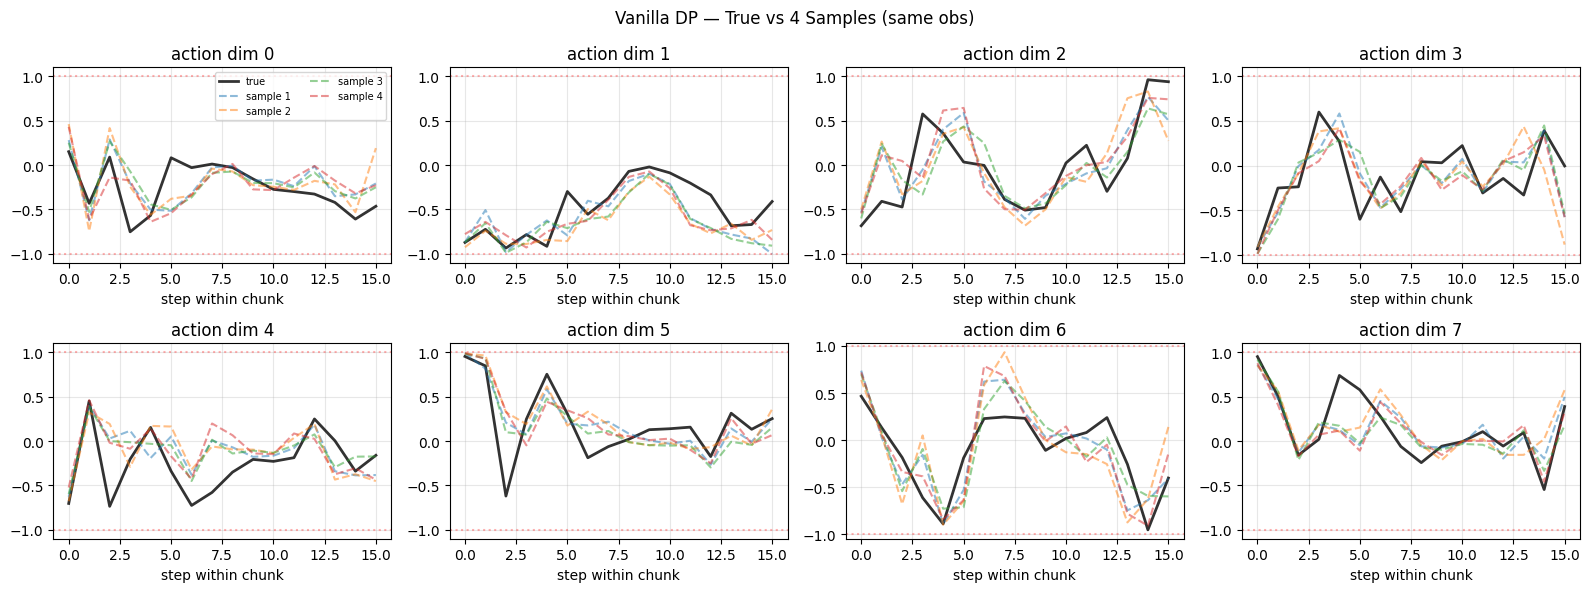

✓ /content/drive/MyDrive/quadruped_diffusion_project/vanilla_dp_chunk_compare.png


In [12]:
ep_obs = val_obs_batch[0:1]
true_chunk = val_act_true[0]

samples = []
for _ in range(4):
    s = sample_action_chunk(
        model, ema, ns_config,
        obs_window=ep_obs,
        cond_fn=vanilla_sample_cond_fn,
        pred_horizon=data['PRED_HORIZON'],
        act_dim=data['ACT_DIM'],
        num_inference_steps=NUM_INFERENCE_STEPS,
        device=device,
    ).numpy()[0]
    samples.append(s)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for d in range(data['ACT_DIM']):
    ax = axes.flat[d]
    ax.plot(true_chunk[:, d], 'k-', linewidth=2, label='true', alpha=0.8)
    for i, s in enumerate(samples):
        ax.plot(s[:, d], '--', alpha=0.5, label=f'sample {i+1}' if d == 0 else None)
    ax.axhline( 1, color='r', ls=':', alpha=0.3)
    ax.axhline(-1, color='r', ls=':', alpha=0.3)
    ax.set_title(f'action dim {d}')
    ax.set_xlabel('step within chunk')
    ax.grid(True, alpha=0.3)
    if d == 0:
        ax.legend(fontsize=7, ncol=2)
plt.suptitle('Vanilla DP — True vs 4 Samples (same obs)')
plt.tight_layout()
out_png = f'{PROJECT_DIR}/vanilla_dp_chunk_compare.png'
plt.savefig(out_png, dpi=80, bbox_inches='tight')
plt.show()
print(f"✓ {out_png}")

## 10. MuJoCo Ant rollout sanity

자빠지지 않고 100+ step 가면 Vanilla DP baseline 작동 확인.

In [14]:
import gymnasium as gym
!pip install -q "gymnasium[mujoco]"

env = gym.make('Ant-v5')
test_obs, _ = env.reset(seed=SEED)
print(f"Ant-v5 default obs dim: {test_obs.shape[0]}")
print(f"학습 OBS_DIM={data['OBS_DIM']} → "
      f"{'일치' if test_obs.shape[0] == data['OBS_DIM'] else '불일치 (truncate 사용)'}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 115.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 27.5 MB/s eta 0:00:00
Ant-v5 default obs dim: 105
학습 OBS_DIM=105 → 일치


In [15]:
print("=== Vanilla DP Rollout (5 seeds) ===\n")
results = rollout_multi_seed(
    model, ema, env, n_seeds=5,
    noise_scheduler_config=ns_config,
    obs_mean=data['obs_mean'], obs_std=data['obs_std'],
    act_min=data['act_min'], act_range=data['act_range'],
    cond_fn=vanilla_sample_cond_fn,
    obs_horizon=data['OBS_HORIZON'],
    pred_horizon=data['PRED_HORIZON'],
    action_horizon=data['ACTION_HORIZON'],
    obs_dim=data['OBS_DIM'],
    act_dim=data['ACT_DIM'],
    num_inference_steps=NUM_INFERENCE_STEPS,
    max_steps=300,
    device=device,
)

surv_mean = np.mean([r['survival'] for r in results])
if surv_mean > 100:
    print("\n✓ Vanilla DP baseline 작동. Step 3 (Periodic Phase Encoding)으로 진행 가능.")
elif surv_mean > 30:
    print("\n△ 부분 작동. 진단 셀로 obs distribution 확인 권장.")
else:
    print("\n✗ 즉시 깨짐. 진단 셀 확인 (obs format mismatch 의심).")

=== Vanilla DP Rollout (5 seeds) ===

  seed 0: survival=300 steps, total_reward=   274.0
  seed 1: survival=300 steps, total_reward=   393.7
  seed 2: survival=300 steps, total_reward=   227.6
  seed 3: survival=300 steps, total_reward=   487.4
  seed 4: survival=300 steps, total_reward=   269.6

Survival:  mean=300 ± 0 steps
Reward:    mean=330.5 ± 96.0

✓ Vanilla DP baseline 작동. Step 3 (Periodic Phase Encoding)으로 진행 가능.


## 11. Rollout 진단 — obs 분포 mismatch 체크

In [16]:
diagnose_obs_distribution(results, data['obs_mean'], data['obs_std'], data['OBS_DIM'])

=== Rollout obs (정규화 후) 분포 ===
전체 mean: -0.030 (학습 분포: ~0)
전체 std:  2.279 (학습 분포: ~1)
|값| > 5 비율: 3.6% (학습 분포: <0.5%; 클수록 mismatch)

차원별 mean (학습 분포 ~0):
  abs(mean) > 1 차원 수: 9/105
  abs(mean) > 3 차원 수: 4/105

Top 5 mismatch 차원:
  dim 1: -11.082
  dim 7: +4.261
  dim 4: +3.588
  dim 13: -3.220
  dim 104: +2.015


{'rollout_obs_n': array([[  1.2601787 ,   2.03980666,   2.04710404, ...,   0.07789185,
          -0.0795789 ,  -0.08891307],
        [  1.07459976,   1.98941782,   2.08358159, ..., -11.26614945,
          11.28393534,  11.24750232],
        [  0.66140241,   1.99749656,   1.54764927, ...,   0.07789185,
          -0.0795789 ,  -0.08891307],
        ...,
        [ -2.00518413, -31.50734806,   0.18036161, ...,   0.07789185,
          -0.0795789 ,  -0.08891307],
        [ -2.00475809, -31.4490455 ,   0.17805812, ...,   0.07789185,
          -0.0795789 ,  -0.08891307],
        [ -1.98623072, -31.38010425,   0.18680622, ...,   0.07789185,
          -0.0795789 ,  -0.08891307]]),
 'dim_means': array([-1.45384283e+00, -1.10817354e+01,  1.73346223e-01,  4.81037130e-01,
         3.58798508e+00,  3.67801783e-01, -1.82843852e-01,  4.26098899e+00,
         1.77279825e-01,  2.18052911e-01,  1.67144725e-01, -6.49916501e-02,
        -5.17980370e-01, -3.21966996e+00,  6.42909463e-02,  1.15169248e-03,
   

## 12. 요약

**완료**:
- src 분리 구조 검증
- Vanilla DP 학습/로드 → sampling sanity → Ant rollout 모두 작동

**Drive 산출물**:
- `vanilla_dp_ckpt.pt` (model + EMA + train log)
- `vanilla_dp_loss.png`
- `vanilla_dp_action_dist.png`
- `vanilla_dp_chunk_compare.png`

**다음 단계 (`03_phase_periodic.ipynb`)**:
- src/models.py에 `build_periodic_phase_dp_model` 함수 한 줄 추가 (`global_cond_dim = OH × OD + 2`)
- 새 노트북 첫 셀들은 이 노트북과 거의 동일 (load → build_loaders → build model)
- `cond_fn=periodic_phase_cond_fn` 으로만 변경
- 학습 / sampling / rollout 동일 함수 호출
- Vanilla 대비 어떤 차이가 나는지 비교

이게 src 분리의 진짜 가치 — Step 3 노트북은 이 노트북에서 **두 줄만 바꾸면** 됨.